# PolyAtlas — Notebook 05i: Four-Model Four-Dataset Robustness Matrix

**Project:** Cross-Campaign Polyreactivity Atlas  
**Notebook:** `PolyAtlas_05i_robustness_matrix`  
**Version:** `v0.1.1`  
**Date:** 2026-04-21

## Purpose

Address the anticipated reviewer critique: 'You ran forward selection on NbBench validation; the feature set is NbBench-specific architecture search that the pretrained LMs did not perform. The 0.834 AUROC may overstate the generality of the finding.'

This notebook provides three independent defenses against that critique plus cross-format evaluation on external conventional-antibody datasets.

## Models (4)

1. **Forward-selected 13-feature CDR-only LR** (from 05h): features chosen via forward selection on NbBench validation. Primary model.
2. **Pre-specified Boughter 21-feature LR**: {length, hydrophobicity, aromatic, charge, arginine, tryptophan, positive fraction} × {H1, H2, H3}. Zero NbBench-guided feature selection; the feature set is directly from Boughter et al. 2020 Nature Communications.
3. **Leave-NbBench-out forward-selected LR**: features chosen via forward selection on combined Boughter+Shehata+Jain (conventional antibody datasets), not NbBench. Uses no NbBench data for feature selection.
4. **H3-charge only zero-training baseline**: single-feature reference (from 05e).

## Datasets (4)

- **NbBench test** (n≈25k, VHH synthetic library): primary evaluation set
- **Boughter 2020** (n≈984, conventional Fab ELISA): cross-format test
- **Shehata 2019** (n≈398, conventional Fab PSR): cross-format test
- **Jain 2017** (n≈137, clinical IgG PSR): cross-format test

## Protocol

- All trainable models fit on NbBench train (n=101,673), frozen, then evaluated on all four test sets with no retraining.
- Model 3 selects features on conventional antibodies but fits LR coefficients on NbBench train. The only NbBench-specific step is the final LR parameter fit.
- LR with `class_weight='balanced'`, StandardScaler, `random_state=42`.
- Bootstrap 500 resamples for 95% CIs on each AUROC.

## Runtime

~15-25 minutes. Feature computation is the slow step; all four models share the same feature catalog.

## What this accomplishes

Three convergent defenses against 'you tuned for NbBench':

1. If **model 2 (Boughter pre-specified)** lands within 0.01-0.02 of model 1 on NbBench, forward selection isn't doing much work — the feature *family* (CDR physicochemistry) captures most of the signal regardless of exact selection.
2. If **model 3 (leave-NbBench-out)** matches model 1 on NbBench, feature selection is robust to choice of selection data — electrostatic mechanism generalizes.
3. If **all models transfer similarly** to conventional antibodies, the NbBench result reflects mechanism-level physicochemistry, not NbBench-specific overfitting.

In [ ]:
from IPython.display import display, Javascript
display(Javascript('''
function ClickConnect(){
    const selectors = ["#top-toolbar > colab-connect-button", "colab-connect-button", "#connect"];
    for (const sel of selectors) {
        const el = document.querySelector(sel);
        if (el) { if (el.shadowRoot) { const inner = el.shadowRoot.querySelector("#connect"); if (inner) { inner.click(); return; } } el.click(); return; }
    }
}
setInterval(ClickConnect, 60000);
'''))

from google.colab import drive
from pathlib import Path
import json

drive.mount('/content/drive', force_remount=True)

DRIVE_ROOT = Path('/content/drive/MyDrive/PolyAtlas')
NOTEBOOK_NAME = "PolyAtlas_05i_robustness_matrix"
PROJECT_VERSION = "0.1.1"
DRIVE_OUTPUT = DRIVE_ROOT / f"{NOTEBOOK_NAME}_v{PROJECT_VERSION}"
DRIVE_OUTPUT.mkdir(parents=True, exist_ok=True)
print(f"Output dir: {DRIVE_OUTPUT}")

<IPython.core.display.Javascript object>

Mounted at /content/drive
Output dir: /content/drive/MyDrive/PolyAtlas/PolyAtlas_05i_robustness_matrix_v0.1.1


In [ ]:
!pip install -q datasets scikit-learn

In [ ]:
import pandas as pd
import numpy as np
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## §1. Feature-building code (same as 05g/05h)

In [ ]:
KYTE_DOOLITTLE = {'A': 1.8,'C': 2.5,'D':-3.5,'E':-3.5,'F': 2.8,'G':-0.4,'H':-3.2,'I': 4.5,'K':-3.9,
                   'L': 3.8,'M': 1.9,'N':-3.5,'P':-1.6,'Q':-3.5,'R':-4.5,'S':-0.8,'T':-0.7,'V': 4.2,
                   'W':-0.9,'Y':-1.3}
CHARGE_AT_PH74 = {'D':-1,'E':-1,'K':+1,'R':+1,'H':+0.1}
AROMATIC = set('FWY')
POSITIVE = set('KR')
NEGATIVE = set('DE')
HYDROPHOBIC = set('ILVFMWYC')
PKA = {'C_term': 3.55, 'D': 4.05, 'E': 4.45, 'H': 5.98, 'K': 10.0, 'R': 12.0, 'Y': 10.0, 'C': 9.0, 'N_term': 8.0}

def net_charge(seq):
    if not isinstance(seq, str) or len(seq) == 0: return np.nan
    return sum(CHARGE_AT_PH74.get(a, 0) for a in seq.upper())

def frac(seq, subset):
    if not isinstance(seq, str) or len(seq) == 0: return np.nan
    s = seq.upper()
    return sum(1 for a in s if a in subset) / len(s)

def frac_residue(seq, residue):
    if not isinstance(seq, str) or len(seq) == 0: return np.nan
    return seq.upper().count(residue) / len(seq)

def mean_hydrophobicity(seq):
    if not isinstance(seq, str) or len(seq) == 0: return np.nan
    return np.mean([KYTE_DOOLITTLE.get(a, 0) for a in seq.upper()])

def max_hydrophobic_run(seq):
    if not isinstance(seq, str) or len(seq) == 0: return 0
    best, cur = 0, 0
    for a in seq.upper():
        if a in HYDROPHOBIC:
            cur += 1
            best = max(best, cur)
        else:
            cur = 0
    return best

def charge_dipole(seq):
    if not isinstance(seq, str) or len(seq) < 4: return 0
    mid = len(seq) // 2
    return net_charge(seq[:mid]) - net_charge(seq[mid:])

def estimate_pI(seq):
    if not isinstance(seq, str) or len(seq) == 0: return np.nan
    s = seq.upper()
    def charge_at_ph(ph):
        c = 0
        c += 1 / (1 + 10**(ph - PKA['N_term']))
        c -= 1 / (1 + 10**(PKA['C_term'] - ph))
        for a in s:
            if a in ('K', 'R'): c += 1 / (1 + 10**(ph - PKA[a]))
            elif a in ('D', 'E'): c -= 1 / (1 + 10**(PKA[a] - ph))
            elif a == 'H': c += 1 / (1 + 10**(ph - PKA['H']))
            elif a == 'Y': c -= 1 / (1 + 10**(PKA['Y'] - ph))
            elif a == 'C': c -= 1 / (1 + 10**(PKA['C'] - ph))
        return c
    lo, hi = 0.0, 14.0
    for _ in range(50):
        mid = (lo + hi) / 2
        if charge_at_ph(mid) > 0: lo = mid
        else: hi = mid
    return (lo + hi) / 2

def build_features(df, cdr1_col='CDR1_nogaps', cdr2_col='CDR2_nogaps', cdr3_col='CDR3_nogaps', full_col='seq'):
    """Build full 52-feature catalog. Column names can be overridden for different schemas."""
    feats = pd.DataFrame(index=df.index)
    for region, col in [('H1', cdr1_col), ('H2', cdr2_col), ('H3', cdr3_col), ('full', full_col)]:
        seqs = df[col].fillna('').astype(str)
        feats[f'{region}_len']         = seqs.str.len()
        feats[f'{region}_charge']      = seqs.apply(net_charge)
        feats[f'{region}_abs_charge']  = feats[f'{region}_charge'].abs()
        feats[f'{region}_pos_frac']    = seqs.apply(lambda s: frac(s, POSITIVE))
        feats[f'{region}_neg_frac']    = seqs.apply(lambda s: frac(s, NEGATIVE))
        feats[f'{region}_hphob']       = seqs.apply(mean_hydrophobicity)
        feats[f'{region}_hphob_frac']  = seqs.apply(lambda s: frac(s, HYDROPHOBIC))
        feats[f'{region}_arom']        = seqs.apply(lambda s: frac(s, AROMATIC))
        feats[f'{region}_W']           = seqs.apply(lambda s: frac_residue(s, 'W'))
        feats[f'{region}_R']           = seqs.apply(lambda s: frac_residue(s, 'R'))
        feats[f'{region}_V']           = seqs.apply(lambda s: frac_residue(s, 'V'))
        feats[f'{region}_G']           = seqs.apply(lambda s: frac_residue(s, 'G'))
    feats['H3_charge_dipole']  = df[cdr3_col].fillna('').astype(str).apply(charge_dipole)
    feats['H3_max_hphob_run']  = df[cdr3_col].fillna('').astype(str).apply(max_hydrophobic_run)
    feats['H3_pI']             = df[cdr3_col].fillna('').astype(str).apply(estimate_pI)
    feats['full_pI']           = df[full_col].fillna('').astype(str).apply(estimate_pI)
    return feats.fillna(0)

## §2. Load all four datasets

- NbBench PolyRx from HuggingFace (has CDR1_nogaps/CDR2_nogaps/CDR3_nogaps/seq built in)
- Boughter/Shehata/Jain from our unified master pickle. We'll need to ensure CDR1/CDR2/CDR3 columns exist for the conventional antibody subset.

In [ ]:
print('Loading NbBench PolyRx...')
ds = load_dataset('ZYMScott/polyreaction')
nb_train_df = ds['train'].to_pandas()
nb_val_df = ds['validation'].to_pandas()
nb_test_df = ds['test'].to_pandas()
print(f'  NbBench train: {nb_train_df.shape}, val: {nb_val_df.shape}, test: {nb_test_df.shape}')

print('\nLoading unified master dataframe...')
MASTER_PKL = '/content/drive/MyDrive/PolyAtlas/PolyAtlas_02c_harvey_ingestion_v0.1.0/unified_master_with_harvey_v0.1.0.pkl'
master_df = pd.read_pickle(MASTER_PKL)
print(f'  Master: {master_df.shape}')
print(f'  Columns (sample): {list(master_df.columns[:20])}')
print(f'  Source breakdown:')
print(master_df['source'].value_counts() if 'source' in master_df.columns else 'NO source column - check schema')

Loading NbBench PolyRx...


README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/16.0M [00:00<?, ?B/s]

val.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/101854 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/14613 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25007 [00:00<?, ? examples/s]

  NbBench train: (101854, 5), val: (14613, 5), test: (25007, 5)

Loading unified master dataframe...
  Master: (9748, 52)
  Columns (sample): ['vh_seq', 'vl_seq', 'name', 'target', 'polyreactivity_psr', 'polyreactivity_bvp', 'polyreactivity_label', 'polyreactivity_score_source', 'tm_fab', 'hic_rt', 'smac_rt', 'ac_sins_dlambda', 'hek_titer', 'cic_rt', 'clinical_status', 'source', 'v_gene_external', 'id', 'species_anarci', 'chain_type']
  Source breakdown:
source
cov_abdab                  3000
harvey_2022                2048
oas_naive                  2000
thera_sabdab                994
boughter_2020_mouse         481
shehata_2019                400
boughter_2020_flu           379
jain_2017                   137
boughter_2020_nat_hiv       134
boughter_2020_gut_hiv        75
boughter_2020_nat_cntrl      50
boughter_2020_plos_hiv       50
Name: count, dtype: int64


In [ ]:
# Inspect master_df schema to figure out which columns contain CDR1/CDR2/CDR3 and labels
# for conventional antibodies. Adjust column names below once we see the actual schema.
print('All columns in master_df:')
for c in master_df.columns:
    print(f'  {c}: dtype={master_df[c].dtype}, non-null={master_df[c].notna().sum()}')

All columns in master_df:
  vh_seq: dtype=object, non-null=7700
  vl_seq: dtype=object, non-null=4371
  name: dtype=object, non-null=7700
  target: dtype=object, non-null=3994
  polyreactivity_psr: dtype=float64, non-null=535
  polyreactivity_bvp: dtype=float64, non-null=137
  polyreactivity_label: dtype=object, non-null=2698
  polyreactivity_score_source: dtype=object, non-null=2700
  tm_fab: dtype=float64, non-null=483
  hic_rt: dtype=float64, non-null=485
  smac_rt: dtype=float64, non-null=137
  ac_sins_dlambda: dtype=float64, non-null=137
  hek_titer: dtype=float64, non-null=137
  cic_rt: dtype=float64, non-null=137
  clinical_status: dtype=object, non-null=137
  source: dtype=object, non-null=9748
  v_gene_external: dtype=object, non-null=3000
  id: dtype=object, non-null=7700
  species_anarci: dtype=object, non-null=7700
  chain_type: dtype=object, non-null=9748
  bitscore: dtype=float64, non-null=7700
  CDR-H1: dtype=object, non-null=9748
  CDR-H2: dtype=object, non-null=9748
  

In [ ]:
# Configure column names for conventional-antibody subsets.
# TODO: The following column names are BEST GUESSES based on the master_df schema.
# Inspect the cell above and update these if needed.

# These columns are what we expect based on the prior work:
CDR1_COL = 'CDR_H1'  # or 'cdr1', 'cdrh1', etc. Inspect master_df above.
CDR2_COL = 'CDR_H2'
CDR3_COL = 'CDR_H3'
FULL_COL = 'VH_seq'  # or 'heavy_chain', 'seq', etc.
LABEL_COL = 'polyreactive_binary'  # or whatever the binary polyreactivity label is called
SOURCE_COL = 'source'

# Auto-detect fallback: search for common column name variants
def autodetect_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

CDR1_COL = autodetect_column(master_df, ['CDR-H1', 'CDR_H1', 'cdr_h1', 'CDRH1', 'cdrh1', 'CDR1', 'cdr1', 'CDR1_nogaps'])
CDR2_COL = autodetect_column(master_df, ['CDR-H2', 'CDR_H2', 'cdr_h2', 'CDRH2', 'cdrh2', 'CDR2', 'cdr2', 'CDR2_nogaps'])
CDR3_COL = autodetect_column(master_df, ['CDR-H3', 'CDR_H3', 'cdr_h3', 'CDRH3', 'cdrh3', 'CDR3', 'cdr3', 'CDR3_nogaps'])
FULL_COL = autodetect_column(master_df, ['vh_seq', 'VH_seq', 'heavy_chain', 'heavy_seq', 'sequence', 'seq', 'full_seq'])
LABEL_COL = autodetect_column(master_df, ['polyreactivity_label', 'polyreactive_binary', 'polyreactive', 'label', 'binary_label', 'is_polyreactive'])
SOURCE_COL = autodetect_column(master_df, ['source', 'dataset', 'study', 'campaign'])

print(f'Detected columns:')
print(f'  CDR1: {CDR1_COL}')
print(f'  CDR2: {CDR2_COL}')
print(f'  CDR3: {CDR3_COL}')
print(f'  FULL: {FULL_COL}')
print(f'  LABEL: {LABEL_COL}')
print(f'  SOURCE: {SOURCE_COL}')

if any(c is None for c in [CDR1_COL, CDR2_COL, CDR3_COL, FULL_COL, LABEL_COL, SOURCE_COL]):
    print('\nWARNING: Some columns not auto-detected. Update the column config above manually and re-run.')

Detected columns:
  CDR1: CDR-H1
  CDR2: CDR-H2
  CDR3: CDR-H3
  FULL: vh_seq
  LABEL: polyreactivity_label
  SOURCE: source


In [ ]:
# Extract conventional-antibody subsets by source
# polyreactivity_label is categorical ('low', 'mid', 'high'); binarize as 'low' -> 0, {'mid','high'} -> 1
def binarize_label(val):
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return np.nan
    s = str(val).lower().strip()
    if s in ('low', '0', 'no', 'non-polyreactive', 'nonpolyreactive', 'negative'):
        return 0
    if s in ('mid', 'high', '1', 'yes', 'polyreactive', 'positive', 'medium'):
        return 1
    return np.nan

sources_available = master_df[SOURCE_COL].value_counts()
print('Available sources:', dict(sources_available))

def extract_source(master_df, source_patterns):
    """Find rows matching any of source_patterns (case-insensitive substring match)."""
    mask = pd.Series(False, index=master_df.index)
    for p in source_patterns:
        mask = mask | master_df[SOURCE_COL].str.contains(p, case=False, na=False)
    return master_df[mask].copy()

boughter_df = extract_source(master_df, ['boughter'])
shehata_df  = extract_source(master_df, ['shehata'])
jain_df     = extract_source(master_df, ['jain', 'adimab'])

def count_with_usable_label(df):
    binarized = df[LABEL_COL].apply(binarize_label)
    return int(binarized.notna().sum())

print(f'\nBoughter subset: n={len(boughter_df)}, with usable (binarized) label: {count_with_usable_label(boughter_df)}')
print(f'Shehata subset:  n={len(shehata_df)}, with usable (binarized) label: {count_with_usable_label(shehata_df)}')
print(f'Jain subset:     n={len(jain_df)}, with usable (binarized) label: {count_with_usable_label(jain_df)}')

# Show raw label distributions per subset so we can sanity-check the binarization
print(f'\nRaw label distributions:')
for name, df in [('Boughter', boughter_df), ('Shehata', shehata_df), ('Jain', jain_df)]:
    dist = df[LABEL_COL].value_counts(dropna=False).to_dict()
    print(f'  {name}: {dist}')

Available sources: {'cov_abdab': np.int64(3000), 'harvey_2022': np.int64(2048), 'oas_naive': np.int64(2000), 'thera_sabdab': np.int64(994), 'boughter_2020_mouse': np.int64(481), 'shehata_2019': np.int64(400), 'boughter_2020_flu': np.int64(379), 'jain_2017': np.int64(137), 'boughter_2020_nat_hiv': np.int64(134), 'boughter_2020_gut_hiv': np.int64(75), 'boughter_2020_nat_cntrl': np.int64(50), 'boughter_2020_plos_hiv': np.int64(50)}

Boughter subset: n=1169, with usable (binarized) label: 1169
Shehata subset:  n=400, with usable (binarized) label: 398
Jain subset:     n=137, with usable (binarized) label: 137

Raw label distributions:
  Boughter: {'high': 501, 'low': 483, 'mid': 185}
  Shehata: {'low': 391, 'high': 7, None: 2}
  Jain: {'low': 93, 'high': 44}


In [ ]:
# Filter conventional-antibody subsets to usable rows and build features
# Uses binarize_label() defined in the previous cell
def prepare_conv(df, name):
    binarized = df[LABEL_COL].apply(binarize_label)
    mask = binarized.notna() & df[CDR3_COL].notna() & (df[CDR3_COL].astype(str).str.len() > 0)
    sub = df[mask].copy().reset_index(drop=True)
    X = build_features(sub, cdr1_col=CDR1_COL, cdr2_col=CDR2_COL, cdr3_col=CDR3_COL, full_col=FULL_COL)
    y = binarized[mask].astype(int).values
    raw_dist = df.loc[mask, LABEL_COL].value_counts().to_dict()
    print(f'  {name}: n={len(y)}, binarized pos={y.sum()}, neg={(y==0).sum()}, raw labels={raw_dist}')
    return X, y, sub

print('Building features for NbBench train/val/test...')
X_nb_train = build_features(nb_train_df)
X_nb_val = build_features(nb_val_df)
X_nb_test = build_features(nb_test_df)
y_nb_train = nb_train_df['label'].astype(int).values
y_nb_val = nb_val_df['label'].astype(int).values
y_nb_test = nb_test_df['label'].astype(int).values

# Drop NbBench rows with empty CDR3
for X, y_ref, name in [(X_nb_train, 'y_nb_train', 'train'), (X_nb_val, 'y_nb_val', 'val'), (X_nb_test, 'y_nb_test', 'test')]:
    keep = X['H3_len'] > 0
    print(f'  NbBench {name}: keeping {keep.sum()}/{len(X)}')

# Filter rows
train_keep = X_nb_train['H3_len'] > 0
val_keep = X_nb_val['H3_len'] > 0
test_keep = X_nb_test['H3_len'] > 0
X_nb_train = X_nb_train[train_keep].reset_index(drop=True); y_nb_train = y_nb_train[train_keep.values]
X_nb_val = X_nb_val[val_keep].reset_index(drop=True); y_nb_val = y_nb_val[val_keep.values]
X_nb_test = X_nb_test[test_keep].reset_index(drop=True); y_nb_test = y_nb_test[test_keep.values]

print('\nBuilding features for conventional-antibody datasets...')
X_bough, y_bough, bough_sub = prepare_conv(boughter_df, 'Boughter')
X_shehata, y_shehata, shehata_sub = prepare_conv(shehata_df, 'Shehata')
X_jain, y_jain, jain_sub = prepare_conv(jain_df, 'Jain')

print(f'\nFinal usable sizes:')
print(f'  NbBench train: n={len(X_nb_train)}, class balance: pos={y_nb_train.sum()} neg={(y_nb_train==0).sum()}')
print(f'  NbBench val:   n={len(X_nb_val)}, class balance: pos={y_nb_val.sum()} neg={(y_nb_val==0).sum()}')
print(f'  NbBench test:  n={len(X_nb_test)}, class balance: pos={y_nb_test.sum()} neg={(y_nb_test==0).sum()}')
print(f'  Boughter:      n={len(X_bough)}, class balance: pos={y_bough.sum()} neg={(y_bough==0).sum()}')
print(f'  Shehata:       n={len(X_shehata)}, class balance: pos={y_shehata.sum()} neg={(y_shehata==0).sum()}')
print(f'  Jain:          n={len(X_jain)}, class balance: pos={y_jain.sum()} neg={(y_jain==0).sum()}')

Building features for NbBench train/val/test...
  NbBench train: keeping 101673/101854
  NbBench val: keeping 14576/14613
  NbBench test: keeping 24955/25007

Building features for conventional-antibody datasets...
  Boughter: n=1169, binarized pos=686, neg=483, raw labels={'high': 501, 'low': 483, 'mid': 185}
  Shehata: n=398, binarized pos=7, neg=391, raw labels={'low': 391, 'high': 7}
  Jain: n=137, binarized pos=44, neg=93, raw labels={'low': 93, 'high': 44}

Final usable sizes:
  NbBench train: n=101673, class balance: pos=50998 neg=50675
  NbBench val:   n=14576, class balance: pos=7316 neg=7260
  NbBench test:  n=24955, class balance: pos=13453 neg=11502
  Boughter:      n=1169, class balance: pos=686 neg=483
  Shehata:       n=398, class balance: pos=7 neg=391
  Jain:          n=137, class balance: pos=44 neg=93


## §3. Define the four models' feature sets

Models 1, 2, 4 have pre-specified feature sets. Model 3 requires running forward selection on conventional-antibody data.

In [ ]:
# Model 1: Forward-selected 13-feature CDR-only from 05h
MODEL1_FEATURES = ['H3_charge', 'H2_charge', 'H1_charge', 'H2_len', 'H3_len', 'H1_arom',
                    'H3_arom', 'H3_neg_frac', 'H3_R', 'H3_abs_charge', 'H2_hphob_frac',
                    'H3_charge_dipole', 'H1_hphob']

# Model 2: Boughter 2020 pre-specified 21 features (7 per CDR x 3 CDRs)
BOUGHTER_7 = ['len', 'hphob', 'arom', 'charge', 'R', 'W', 'pos_frac']
MODEL2_FEATURES = [f'{region}_{feat}' for region in ['H1', 'H2', 'H3'] for feat in BOUGHTER_7]

# Model 4: H3 charge only (zero-training)
MODEL4_FEATURES = ['H3_charge']

print(f'Model 1 (forward-selected on NbBench val): {len(MODEL1_FEATURES)} features')
print(f'  {MODEL1_FEATURES}')
print(f'\nModel 2 (Boughter 2020 pre-specified):     {len(MODEL2_FEATURES)} features')
print(f'  {MODEL2_FEATURES}')
print(f'\nModel 4 (H3 charge baseline):              {len(MODEL4_FEATURES)} features')

# Overlap check
shared_1_2 = set(MODEL1_FEATURES) & set(MODEL2_FEATURES)
print(f'\nOverlap between Model 1 and Model 2: {len(shared_1_2)} features: {sorted(shared_1_2)}')

Model 1 (forward-selected on NbBench val): 13 features
  ['H3_charge', 'H2_charge', 'H1_charge', 'H2_len', 'H3_len', 'H1_arom', 'H3_arom', 'H3_neg_frac', 'H3_R', 'H3_abs_charge', 'H2_hphob_frac', 'H3_charge_dipole', 'H1_hphob']

Model 2 (Boughter 2020 pre-specified):     21 features
  ['H1_len', 'H1_hphob', 'H1_arom', 'H1_charge', 'H1_R', 'H1_W', 'H1_pos_frac', 'H2_len', 'H2_hphob', 'H2_arom', 'H2_charge', 'H2_R', 'H2_W', 'H2_pos_frac', 'H3_len', 'H3_hphob', 'H3_arom', 'H3_charge', 'H3_R', 'H3_W', 'H3_pos_frac']

Model 4 (H3 charge baseline):              1 features

Overlap between Model 1 and Model 2: 9 features: ['H1_arom', 'H1_charge', 'H1_hphob', 'H2_charge', 'H2_len', 'H3_R', 'H3_arom', 'H3_charge', 'H3_len']


## §4. Model 3: Forward selection on combined conventional-antibody data

Pool Boughter + Shehata + Jain into one training+validation set for feature selection. Features are chosen entirely without looking at NbBench data. After selection, the feature set is frozen and Model 3's LR coefficients are fit on NbBench train (same protocol as Models 1 and 2).

In [ ]:
# Pool conventional-antibody features and labels
X_conv_pool = pd.concat([X_bough, X_shehata, X_jain], ignore_index=True)
y_conv_pool = np.concatenate([y_bough, y_shehata, y_jain])
source_pool = ['Boughter'] * len(X_bough) + ['Shehata'] * len(X_shehata) + ['Jain'] * len(X_jain)

print(f'Conventional-antibody pool: n={len(X_conv_pool)}, pos={y_conv_pool.sum()}, neg={(y_conv_pool==0).sum()}')

# Restrict candidate features to CDR-only (no full_*) for consistency with Model 1
CDR_ONLY_CANDIDATES = [f for f in X_conv_pool.columns if not f.startswith('full_')]
print(f'CDR-only candidates for selection: {len(CDR_ONLY_CANDIDATES)}')

# Forward selection using 5-fold CV on the conventional pool (pool is small so single-split selection would be noisy)
from sklearn.model_selection import StratifiedKFold

def forward_select_cv(X_pool, y_pool, candidate_pool, seed_feature='H3_charge',
                       max_features=15, min_gain=0.001, n_folds=5):
    """Forward selection using stratified k-fold CV AUROC on the pool."""
    selected = [seed_feature]
    remaining = [f for f in candidate_pool if f != seed_feature]
    kf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

    def cv_auroc(feat_set):
        aucs = []
        for tr_idx, va_idx in kf.split(X_pool, y_pool):
            sc = StandardScaler().fit(X_pool.iloc[tr_idx][feat_set].values)
            lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=300)
            lr.fit(sc.transform(X_pool.iloc[tr_idx][feat_set].values), y_pool[tr_idx])
            scores = lr.predict_proba(sc.transform(X_pool.iloc[va_idx][feat_set].values))[:, 1]
            aucs.append(roc_auc_score(y_pool[va_idx], scores))
        return np.mean(aucs)

    current_auc = cv_auroc(selected)
    print(f'Step 0 ({seed_feature} alone): 5-fold CV AUROC = {current_auc:.4f}')
    history = [{'step': 0, 'added': seed_feature, 'n_features': 1, 'cv_AUROC': current_auc, 'gain': current_auc}]

    step = 0
    while len(selected) < max_features and len(remaining) > 0:
        step += 1
        best_gain = -np.inf
        best_feat = None
        best_auc = None
        for cand in remaining:
            trial = selected + [cand]
            auc = cv_auroc(trial)
            gain = auc - current_auc
            if gain > best_gain:
                best_gain = gain
                best_feat = cand
                best_auc = auc
        print(f'Step {step}: + {best_feat:<22} CV AUROC = {best_auc:.4f} (gain {best_gain:+.4f})')
        if best_gain < min_gain and step >= 5:
            print(f'  Stopping: gain below threshold')
            break
        selected.append(best_feat)
        remaining.remove(best_feat)
        current_auc = best_auc
        history.append({'step': step, 'added': best_feat, 'n_features': len(selected),
                         'cv_AUROC': best_auc, 'gain': best_gain})

    return selected, history

print('Running forward selection on conventional-antibody pool...')
MODEL3_FEATURES, model3_history = forward_select_cv(
    X_conv_pool, y_conv_pool, CDR_ONLY_CANDIDATES,
    seed_feature='H3_charge', max_features=15, min_gain=0.001, n_folds=5
)
print(f'\nModel 3 final feature set ({len(MODEL3_FEATURES)}): {MODEL3_FEATURES}')
print(f'\nComparison with Model 1 features:')
print(f'  Model 1 (NbBench val-selected):    {MODEL1_FEATURES}')
print(f'  Model 3 (conv.-Ab-pool-selected):  {MODEL3_FEATURES}')
shared_1_3 = set(MODEL1_FEATURES) & set(MODEL3_FEATURES)
print(f'  Shared features: {len(shared_1_3)}/{max(len(MODEL1_FEATURES), len(MODEL3_FEATURES))}: {sorted(shared_1_3)}')

Conventional-antibody pool: n=1704, pos=737, neg=967
CDR-only candidates for selection: 39
Running forward selection on conventional-antibody pool...
Step 0 (H3_charge alone): 5-fold CV AUROC = 0.5692
Step 1: + H1_charge              CV AUROC = 0.5890 (gain +0.0198)
Step 2: + H2_neg_frac            CV AUROC = 0.5972 (gain +0.0082)
Step 3: + H3_len                 CV AUROC = 0.6050 (gain +0.0078)
Step 4: + H2_R                   CV AUROC = 0.6131 (gain +0.0081)
Step 5: + H2_W                   CV AUROC = 0.6169 (gain +0.0038)
Step 6: + H3_hphob_frac          CV AUROC = 0.6202 (gain +0.0033)
Step 7: + H3_R                   CV AUROC = 0.6238 (gain +0.0037)
Step 8: + H3_hphob               CV AUROC = 0.6294 (gain +0.0055)
Step 9: + H2_len                 CV AUROC = 0.6311 (gain +0.0018)
Step 10: + H2_hphob               CV AUROC = 0.6324 (gain +0.0013)
Step 11: + H3_max_hphob_run       CV AUROC = 0.6344 (gain +0.0020)
Step 12: + H1_len                 CV AUROC = 0.6348 (gain +0.0003)
  St

## §5. Train each model on NbBench train, evaluate on all four datasets

Models 1, 2, 3 are LR fit on NbBench train. Model 4 is zero-training (raw charge score).

In [ ]:
MODELS = {
    f'Model 1: Forward-selected ({len(MODEL1_FEATURES)} feats)': {'features': MODEL1_FEATURES, 'trainable': True},
    f'Model 2: Boughter 2020 pre-specified ({len(MODEL2_FEATURES)} feats)': {'features': MODEL2_FEATURES, 'trainable': True},
    f'Model 3: Leave-NbBench-out ({len(MODEL3_FEATURES)} feats)': {'features': MODEL3_FEATURES, 'trainable': True},
    f'Model 4: H3_charge zero-training': {'features': MODEL4_FEATURES, 'trainable': False},
}

DATASETS = {
    'NbBench test':  (X_nb_test, y_nb_test),
    'Boughter 2020': (X_bough, y_bough),
    'Shehata 2019':  (X_shehata, y_shehata),
    'Jain 2017':     (X_jain, y_jain),
}

B_BOOT = 500
rng = np.random.RandomState(42)

results_matrix = {}
for model_name, cfg in MODELS.items():
    print(f'\n{"=" * 75}\n{model_name}\n{"=" * 75}')
    feats = cfg['features']
    if cfg['trainable']:
        sc = StandardScaler().fit(X_nb_train[feats].values)
        lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=500)
        lr.fit(sc.transform(X_nb_train[feats].values), y_nb_train)
        scoring_fn = lambda X: lr.predict_proba(sc.transform(X[feats].values))[:, 1]
    else:
        # Zero-training: score is raw charge value
        scoring_fn = lambda X: X[feats[0]].values

    row = {}
    for ds_name, (X_ds, y_ds) in DATASETS.items():
        scores = scoring_fn(X_ds)
        # Guard against single-class evaluation sets
        if len(np.unique(y_ds)) < 2:
            print(f'  {ds_name}: SKIPPED (single-class)')
            row[ds_name] = {'AUROC': np.nan, 'AUPRC': np.nan, 'ci_lo': np.nan, 'ci_hi': np.nan, 'n': len(y_ds)}
            continue
        auc = roc_auc_score(y_ds, scores)
        auprc = average_precision_score(y_ds, scores)
        # Bootstrap
        boot_aucs = []
        for b in range(B_BOOT):
            idx = rng.choice(len(y_ds), size=len(y_ds), replace=True)
            try:
                boot_aucs.append(roc_auc_score(y_ds[idx], scores[idx]))
            except ValueError:
                pass
        ci_lo = np.percentile(boot_aucs, 2.5) if boot_aucs else np.nan
        ci_hi = np.percentile(boot_aucs, 97.5) if boot_aucs else np.nan
        print(f'  {ds_name:<15} n={len(y_ds):>5}  AUROC = {auc:.4f}  [{ci_lo:.4f}, {ci_hi:.4f}]  AUPRC = {auprc:.4f}')
        row[ds_name] = {'AUROC': auc, 'AUPRC': auprc, 'ci_lo': ci_lo, 'ci_hi': ci_hi, 'n': len(y_ds)}
    results_matrix[model_name] = row


Model 1: Forward-selected (13 feats)
  NbBench test    n=24955  AUROC = 0.8336  [0.8281, 0.8389]  AUPRC = 0.8364
  Boughter 2020   n= 1169  AUROC = 0.4922  [0.4592, 0.5225]  AUPRC = 0.5898
  Shehata 2019    n=  398  AUROC = 0.5656  [nan, nan]  AUPRC = 0.0215
  Jain 2017       n=  137  AUROC = 0.6045  [0.5003, 0.7047]  AUPRC = 0.3946

Model 2: Boughter 2020 pre-specified (21 feats)
  NbBench test    n=24955  AUROC = 0.8289  [0.8240, 0.8338]  AUPRC = 0.8301
  Boughter 2020   n= 1169  AUROC = 0.5023  [0.4682, 0.5323]  AUPRC = 0.5931
  Shehata 2019    n=  398  AUROC = 0.6332  [nan, nan]  AUPRC = 0.0253
  Jain 2017       n=  137  AUROC = 0.5989  [0.4923, 0.7040]  AUPRC = 0.3924

Model 3: Leave-NbBench-out (12 feats)
  NbBench test    n=24955  AUROC = 0.8171  [0.8120, 0.8227]  AUPRC = 0.8170
  Boughter 2020   n= 1169  AUROC = 0.5372  [0.5026, 0.5686]  AUPRC = 0.6137
  Shehata 2019    n=  398  AUROC = 0.4607  [nan, nan]  AUPRC = 0.0178
  Jain 2017       n=  137  AUROC = 0.6025  [0.4992, 0.70

## §6. Summary table: 4 models x 4 datasets

In [ ]:
# Build a wide AUROC table
auroc_table = pd.DataFrame({
    model: {ds: results_matrix[model][ds]['AUROC'] for ds in DATASETS.keys()}
    for model in MODELS.keys()
}).T
auroc_table.index.name = 'Model'
auroc_table.to_csv(DRIVE_OUTPUT / 'auroc_matrix.csv')

print('AUROC matrix (4 models x 4 datasets):')
print(auroc_table.to_string(float_format=lambda x: f'{x:.4f}'))

# Build a CI-annotated version
def fmt_cell(model, ds):
    r = results_matrix[model][ds]
    if np.isnan(r['AUROC']): return '--'
    return f"{r['AUROC']:.3f} [{r['ci_lo']:.3f}, {r['ci_hi']:.3f}]"

annotated_table = pd.DataFrame({
    model: {ds: fmt_cell(model, ds) for ds in DATASETS.keys()}
    for model in MODELS.keys()
}).T
annotated_table.index.name = 'Model'
annotated_table.to_csv(DRIVE_OUTPUT / 'auroc_matrix_with_ci.csv')
print('\nAUROC with 95% CIs:')
print(annotated_table.to_string())

AUROC matrix (4 models x 4 datasets):
                                                 NbBench test  Boughter 2020  Shehata 2019  Jain 2017
Model                                                                                                
Model 1: Forward-selected (13 feats)                   0.8336         0.4922        0.5656     0.6045
Model 2: Boughter 2020 pre-specified (21 feats)        0.8289         0.5023        0.6332     0.5989
Model 3: Leave-NbBench-out (12 feats)                  0.8171         0.5372        0.4607     0.6025
Model 4: H3_charge zero-training                       0.7262         0.6001        0.7013     0.5908

AUROC with 95% CIs:
                                                         NbBench test         Boughter 2020      Shehata 2019             Jain 2017
Model                                                                                                                              
Model 1: Forward-selected (13 feats)             0.834 [0.828, 0.

## §7. Key pairwise comparisons for reviewer defense

- Model 1 vs Model 2 on NbBench: does forward selection help over Boughter pre-specified?
- Model 1 vs Model 3 on NbBench: is our selected feature set robust to choice of selection data?
- Model 1 across datasets: how much does cross-format transfer degrade performance?

In [ ]:
m1_key = [k for k in MODELS.keys() if k.startswith('Model 1')][0]
m2_key = [k for k in MODELS.keys() if k.startswith('Model 2')][0]
m3_key = [k for k in MODELS.keys() if k.startswith('Model 3')][0]

print('='*80)
print('KEY COMPARISONS')
print('='*80)

nb_test_str = 'NbBench test'
delta_1_2 = results_matrix[m1_key][nb_test_str]['AUROC'] - results_matrix[m2_key][nb_test_str]['AUROC']
print(f'\nDefense 1: Does feature selection help over Boughter pre-specified?')
print(f'  Model 1 (forward-selected, 13 feats): NbBench test AUROC = {results_matrix[m1_key][nb_test_str]["AUROC"]:.4f}')
print(f'  Model 2 (Boughter 21 pre-specified):   NbBench test AUROC = {results_matrix[m2_key][nb_test_str]["AUROC"]:.4f}')
print(f'  Delta: {delta_1_2:+.4f}  (<0.01 means Boughter features already capture the signal)')

delta_1_3 = results_matrix[m1_key][nb_test_str]['AUROC'] - results_matrix[m3_key][nb_test_str]['AUROC']
print(f'\nDefense 2: Does feature selection depend on what data we selected on?')
print(f'  Model 1 (selected on NbBench val):         {results_matrix[m1_key][nb_test_str]["AUROC"]:.4f}')
print(f'  Model 3 (selected on conv. Ab pool only):  {results_matrix[m3_key][nb_test_str]["AUROC"]:.4f}')
print(f'  Delta: {delta_1_3:+.4f}  (<0.01 means feature choice is robust)')

print(f'\nDefense 3: Cross-format transfer (Model 1 across datasets)')
nbbench_auc = results_matrix[m1_key][nb_test_str]['AUROC']
for ds in ['Boughter 2020', 'Shehata 2019', 'Jain 2017']:
    r = results_matrix[m1_key][ds]
    drop = nbbench_auc - r['AUROC']
    print(f'  {ds:<20} n={r["n"]:>4}  AUROC = {r["AUROC"]:.4f}  (drop from NbBench: {drop:+.4f})')

KEY COMPARISONS

Defense 1: Does feature selection help over Boughter pre-specified?
  Model 1 (forward-selected, 13 feats): NbBench test AUROC = 0.8336
  Model 2 (Boughter 21 pre-specified):   NbBench test AUROC = 0.8289
  Delta: +0.0047  (<0.01 means Boughter features already capture the signal)

Defense 2: Does feature selection depend on what data we selected on?
  Model 1 (selected on NbBench val):         0.8336
  Model 3 (selected on conv. Ab pool only):  0.8171
  Delta: +0.0165  (<0.01 means feature choice is robust)

Defense 3: Cross-format transfer (Model 1 across datasets)
  Boughter 2020        n=1169  AUROC = 0.4922  (drop from NbBench: +0.3414)
  Shehata 2019         n= 398  AUROC = 0.5656  (drop from NbBench: +0.2681)
  Jain 2017            n= 137  AUROC = 0.6045  (drop from NbBench: +0.2292)


## §8. Comparison with NbBench Table 10 on NbBench test

In [ ]:
nbbench_table10 = {
    'ProtBert': 0.837, 'ESM-2 (150M)': 0.833, 'ESM-2 (650M)': 0.842,
    'AbLang-H': 0.831, 'AbLang-L': 0.819, 'AntiBERTy': 0.828,
    'AntiBERTa2': 0.833, 'AntiBERTa2-CSSP': 0.830, 'IgBert': 0.829,
    'NanoBERT': 0.815, 'VHHBERT': 0.818,
}

rows = [
    {'model': m1_key, 'AUROC': results_matrix[m1_key][nb_test_str]['AUROC'], 'type': 'hand-crafted, selected'},
    {'model': m2_key, 'AUROC': results_matrix[m2_key][nb_test_str]['AUROC'], 'type': 'hand-crafted, pre-specified'},
    {'model': m3_key, 'AUROC': results_matrix[m3_key][nb_test_str]['AUROC'], 'type': 'hand-crafted, selected off-NbBench'},
    {'model': 'H3 charge zero-training', 'AUROC': results_matrix[[k for k in MODELS if k.startswith('Model 4')][0]][nb_test_str]['AUROC'], 'type': 'hand-crafted, zero-training'},
]
for name, auc in nbbench_table10.items():
    rows.append({'model': name, 'AUROC': auc, 'type': 'language model'})

comp = pd.DataFrame(rows).sort_values('AUROC', ascending=False).reset_index(drop=True)
comp.insert(0, 'rank', range(1, len(comp) + 1))
comp.to_csv(DRIVE_OUTPUT / 'comparison_with_nbbench.csv', index=False)

print('NbBench test AUROC ranking (our four models + 11 NbBench LMs):')
print(comp.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

for m in [m1_key, m2_key, m3_key]:
    row = comp[comp['model'] == m]
    if len(row) > 0:
        r = row.iloc[0]
        n_beat = sum(1 for a in nbbench_table10.values() if a < r['AUROC'])
        print(f'\n{m}: rank {int(r["rank"])}, beats {n_beat}/11 LMs')

NbBench test AUROC ranking (our four models + 11 NbBench LMs):
 rank                                           model  AUROC                               type
    1                                    ESM-2 (650M) 0.8420                     language model
    2                                        ProtBert 0.8370                     language model
    3            Model 1: Forward-selected (13 feats) 0.8336             hand-crafted, selected
    4                                    ESM-2 (150M) 0.8330                     language model
    5                                      AntiBERTa2 0.8330                     language model
    6                                        AbLang-H 0.8310                     language model
    7                                 AntiBERTa2-CSSP 0.8300                     language model
    8                                          IgBert 0.8290                     language model
    9 Model 2: Boughter 2020 pre-specified (21 feats) 0.8289        hand-

## §9. Visualization: 4x4 heatmap with CIs

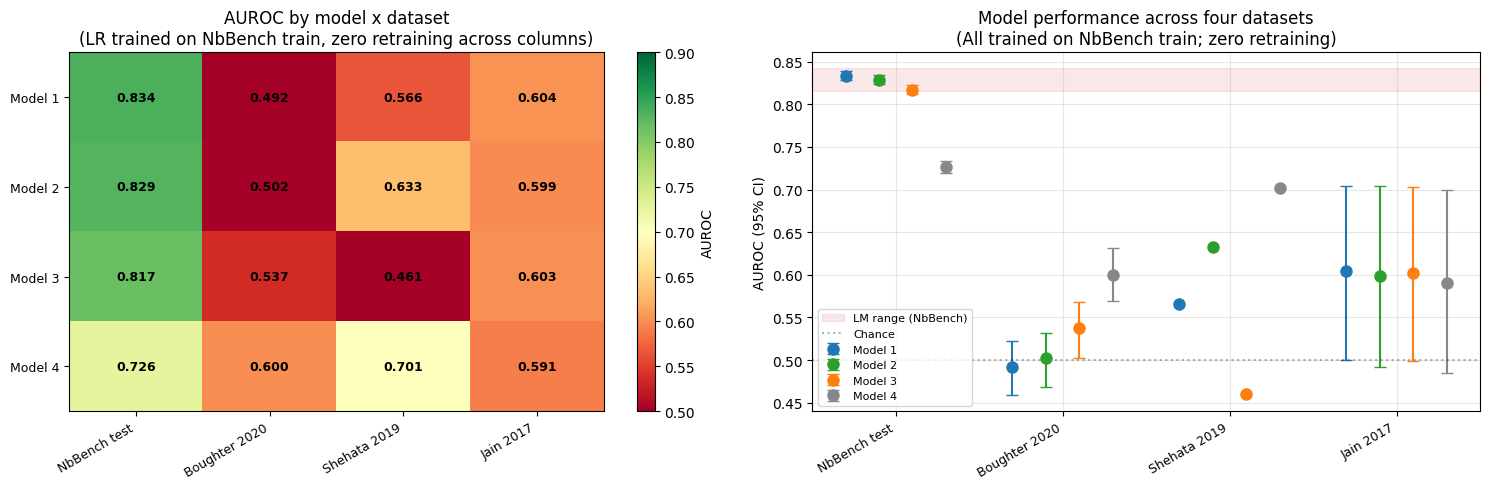

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: heatmap of AUROC across 4x4 matrix
ax = axes[0]
heatmap_data = auroc_table.values
im = ax.imshow(heatmap_data, aspect='auto', cmap='RdYlGn', vmin=0.5, vmax=0.9)
ax.set_xticks(range(len(auroc_table.columns)))
ax.set_xticklabels(auroc_table.columns, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(auroc_table.index)))
ax.set_yticklabels([m.split(':')[0] for m in auroc_table.index], fontsize=9)
for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        if not np.isnan(heatmap_data[i, j]):
            ax.text(j, i, f'{heatmap_data[i, j]:.3f}', ha='center', va='center', fontsize=9,
                     color='black', fontweight='bold')
ax.set_title('AUROC by model x dataset\n(LR trained on NbBench train, zero retraining across columns)')
plt.colorbar(im, ax=ax, label='AUROC')

# Right: model 1 AUROC with CIs across datasets
ax = axes[1]
model_names = list(MODELS.keys())
x_pos = np.arange(len(DATASETS))
width = 0.2
colors_m = ['#1f77b4', '#2ca02c', '#ff7f0e', '#888888']
for mi, mname in enumerate(model_names):
    aucs = [results_matrix[mname][d]['AUROC'] for d in DATASETS.keys()]
    err_lo = [results_matrix[mname][d]['AUROC'] - results_matrix[mname][d]['ci_lo'] for d in DATASETS.keys()]
    err_hi = [results_matrix[mname][d]['ci_hi'] - results_matrix[mname][d]['AUROC'] for d in DATASETS.keys()]
    aucs = np.array(aucs)
    err_lo = np.array(err_lo)
    err_hi = np.array(err_hi)
    mask = ~np.isnan(aucs)
    ax.errorbar(x_pos[mask] + (mi - 1.5) * width, aucs[mask], yerr=[err_lo[mask], err_hi[mask]],
                 fmt='o', capsize=4, markersize=8, color=colors_m[mi],
                 label=mname.split(':')[0])
ax.fill_between([-0.5, len(DATASETS) - 0.5], 0.815, 0.842, alpha=0.1, color='#d62728', label='LM range (NbBench)')
ax.axhline(0.5, color='k', linestyle=':', alpha=0.3, label='Chance')
ax.set_xticks(x_pos)
ax.set_xticklabels(list(DATASETS.keys()), rotation=30, ha='right', fontsize=9)
ax.set_ylabel('AUROC (95% CI)')
ax.set_title('Model performance across four datasets\n(All trained on NbBench train; zero retraining)')
ax.legend(loc='lower left', fontsize=8)
ax.grid(alpha=0.3)
ax.set_xlim(-0.5, len(DATASETS) - 0.5)

plt.tight_layout()
plt.savefig(DRIVE_OUTPUT / 'robustness_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## §10. Save summary

In [ ]:
summary = {
    'version': PROJECT_VERSION,
    'models': {
        'Model 1 (forward-selected)': MODEL1_FEATURES,
        'Model 2 (Boughter pre-specified)': MODEL2_FEATURES,
        'Model 3 (leave-NbBench-out)': MODEL3_FEATURES,
        'Model 4 (H3 charge zero-training)': MODEL4_FEATURES,
    },
    'model3_selection_history': model3_history,
    'results_matrix': {m: {d: results_matrix[m][d] for d in DATASETS.keys()} for m in MODELS.keys()},
    'dataset_sizes': {d: int(len(DATASETS[d][1])) for d in DATASETS.keys()},
    'defenses': {
        'boughter_vs_forward_delta': float(delta_1_2),
        'leave_nbbench_out_vs_forward_delta': float(delta_1_3),
    },
}
with open(DRIVE_OUTPUT / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print('Outputs saved to:', DRIVE_OUTPUT)
print()
print('='*80)
print('HEADLINE')
print('='*80)
print(f'{"Model":<45}{"NbBench":>10}{"Boughter":>10}{"Shehata":>10}{"Jain":>10}')
print('-'*80)
for m in MODELS.keys():
    name_short = m.split(':')[1].strip().split('(')[0].strip() if ':' in m else m
    cells = [f'{results_matrix[m][d]["AUROC"]:.3f}' if not np.isnan(results_matrix[m][d]['AUROC']) else '---' for d in DATASETS.keys()]
    print(f'{m[:43]:<45}{cells[0]:>10}{cells[1]:>10}{cells[2]:>10}{cells[3]:>10}')

Outputs saved to: /content/drive/MyDrive/PolyAtlas/PolyAtlas_05i_robustness_matrix_v0.1.1

HEADLINE
Model                                           NbBench  Boughter   Shehata      Jain
--------------------------------------------------------------------------------
Model 1: Forward-selected (13 feats)              0.834     0.492     0.566     0.604
Model 2: Boughter 2020 pre-specified (21 fe       0.829     0.502     0.633     0.599
Model 3: Leave-NbBench-out (12 feats)             0.817     0.537     0.461     0.603
Model 4: H3_charge zero-training                  0.726     0.600     0.701     0.591
